# Exercise 1

In [1]:
seed = 0.2481
random_number = []
for i in range(100):
    y = seed**2
    seed = y*1000000
    seed = (int(seed) % 10000) / 10000
    random_number.append(seed)


In [2]:
print(random_number)

[0.1553, 0.4118, 0.9579, 0.7572, 0.3351, 0.2292, 0.2532, 0.411, 0.8921, 0.5842, 0.1289, 0.6615, 0.7582, 0.4867, 0.6876, 0.2793, 0.8008, 0.128, 0.6384, 0.7554, 0.0629, 0.3956, 0.6499, 0.237, 0.6169, 0.0565, 0.3192, 0.1888, 0.5645, 0.866, 0.9956, 0.1219, 0.4859, 0.6098, 0.1856, 0.4447, 0.7758, 0.1865, 0.4782, 0.8675, 0.2556, 0.5331, 0.4195, 0.598, 0.7604, 0.8208, 0.3712, 0.7789, 0.6685, 0.6892, 0.4996, 0.96, 0.16, 0.56, 0.36, 0.96, 0.16, 0.56, 0.36, 0.96, 0.16, 0.56, 0.36, 0.96, 0.16, 0.56, 0.36, 0.96, 0.16, 0.56, 0.36, 0.96, 0.16, 0.56, 0.36, 0.96, 0.16, 0.56, 0.36, 0.96, 0.16, 0.56, 0.36, 0.96, 0.16, 0.56, 0.36, 0.96, 0.16, 0.56, 0.36, 0.96, 0.16, 0.56, 0.36, 0.96, 0.16, 0.56, 0.36, 0.96]


### Validation of the generator

1. **The Mean**: For a uniform distribution $U(0, 1)$, the theoretical mean is $E[U] = \frac{1}{2}$.
2. **The Variance**: The theoretical variance converges in probability $Var(U) = \frac{1}{12}$.
3. **Uniformity**: The generated values should be uniformly distributed over the interval $[0, 1]$, often verified using the Chi-square or Kolmogorov-Smirnov tests.
4. **Independence (Autocorrelation)**: The sequence of numbers should be independent, meaning the autocorrelation $\rho(k)$ for any lag $k > 0$ should be zero.
5. **Periodicity**: The generator should have a sufficiently long period before the sequence of numbers begins to repeat.

In [3]:
# Mean
sum = 0
for i in random_number:
    sum+=i
sum/=random_number.__len__()
print(f"The mean ={sum}")

The mean =0.512554


In [4]:
# Variance
import numpy as np
var = 0
for i in random_number:
    var += (i - np.mean(random_number))**2
var = var / len(random_number)
print(var)

0.07751458768400005


In [5]:
import numpy as np

random_number = np.array(random_number)

m = 10
n = len(random_number)
V = np.zeros(m)
for j in range(1, m + 1):
    left = (j - 1) / m
    right = j / m
    Vj = ((random_number >= left) & (random_number < right)).sum()
    V[j-1] = Vj
    print(f"V_{j}/n = {Vj/n}")


V_1/n = 0.02
V_2/n = 0.19
V_3/n = 0.05
V_4/n = 0.16
V_5/n = 0.08
V_6/n = 0.16
V_7/n = 0.08
V_8/n = 0.06
V_9/n = 0.05
V_10/n = 0.15


#### **Chi-Squared Uniformity Test**
$$p_{j} = \frac{longueur de I_{j}}{1-0}$$
we calculate $$W= \sum_{j=1}^{m}\frac{ (V_{j}-n*p_{j})^{2}}{n*p_{j}}$$

In [6]:
# Chi-Squared Uniformity Test
# H0 : The data is uniformly distributed
# H1 : The data is not uniformly distributed

from scipy.stats import chi2
sum =0
for j in range(m):
    sum +=(V[j-1]-n/m)**2/(n/m)
print(f"W = {sum}, {chi2.ppf(0.95, m-1)}")

if sum < chi2.ppf(0.95, m-1):
    print("we accept H0")
else:
    print("We reject H0")
    

W = 31.6, 16.918977604620448
We reject H0


# Exercise 2

In [25]:
a = 17
b = 43
m = 100
y = 27
n = 30
def generator(a,b,y,m,n):
    random_numbers = []
    for i in range(n):
        y = (a * y + b) % m
        random_numbers.append(y/m)
    return random_numbers
print(generator(a,b,y,m,n))

[0.02, 0.77, 0.52, 0.27, 0.02, 0.77, 0.52, 0.27, 0.02, 0.77, 0.52, 0.27, 0.02, 0.77, 0.52, 0.27, 0.02, 0.77, 0.52, 0.27, 0.02, 0.77, 0.52, 0.27, 0.02, 0.77, 0.52, 0.27, 0.02, 0.77]


In [41]:
random_numbers = []
for i in range(1, 28):
    random_numbers.append(generator(a, b, i, m, n))

In [42]:
print(random_numbers)

[[0.6, 0.63, 0.14, 0.81, 0.2, 0.83, 0.54, 0.61, 0.8, 0.03, 0.94, 0.41, 0.4, 0.23, 0.34, 0.21, 0.0, 0.43, 0.74, 0.01, 0.6, 0.63, 0.14, 0.81, 0.2, 0.83, 0.54, 0.61, 0.8, 0.03], [0.77, 0.52, 0.27, 0.02, 0.77, 0.52, 0.27, 0.02, 0.77, 0.52, 0.27, 0.02, 0.77, 0.52, 0.27, 0.02, 0.77, 0.52, 0.27, 0.02, 0.77, 0.52, 0.27, 0.02, 0.77, 0.52, 0.27, 0.02, 0.77, 0.52], [0.94, 0.41, 0.4, 0.23, 0.34, 0.21, 0.0, 0.43, 0.74, 0.01, 0.6, 0.63, 0.14, 0.81, 0.2, 0.83, 0.54, 0.61, 0.8, 0.03, 0.94, 0.41, 0.4, 0.23, 0.34, 0.21, 0.0, 0.43, 0.74, 0.01], [0.11, 0.3, 0.53, 0.44, 0.91, 0.9, 0.73, 0.84, 0.71, 0.5, 0.93, 0.24, 0.51, 0.1, 0.13, 0.64, 0.31, 0.7, 0.33, 0.04, 0.11, 0.3, 0.53, 0.44, 0.91, 0.9, 0.73, 0.84, 0.71, 0.5], [0.28, 0.19, 0.66, 0.65, 0.48, 0.59, 0.46, 0.25, 0.68, 0.99, 0.26, 0.85, 0.88, 0.39, 0.06, 0.45, 0.08, 0.79, 0.86, 0.05, 0.28, 0.19, 0.66, 0.65, 0.48, 0.59, 0.46, 0.25, 0.68, 0.99], [0.45, 0.08, 0.79, 0.86, 0.05, 0.28, 0.19, 0.66, 0.65, 0.48, 0.59, 0.46, 0.25, 0.68, 0.99, 0.26, 0.85, 0.88, 0.3

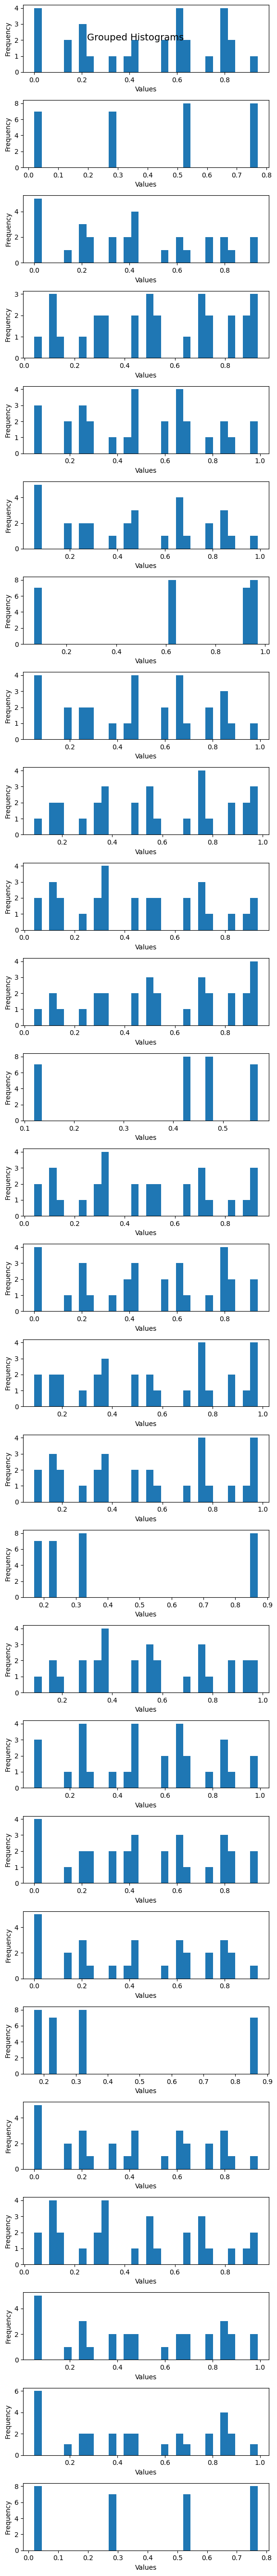

In [48]:
import matplotlib.pyplot as plt

k = len(random_numbers)
fig, axes = plt.subplots(k, 1, figsize=(6, 2*k))

for ax, data in zip(axes, random_numbers):
    ax.hist(data, bins=30)
    ax.set_xlabel('Values')
    ax.set_ylabel('Frequency')

fig.suptitle('Grouped Histograms', fontsize=14)
plt.tight_layout()
plt.show()
